# Training an image-to-image (virtual staining) model with BiaPy

In `data_collection_IDR_stardist.ipynb` a training data set was created, consisting of phalloidin images in
`images/` and the corresponding raw DAPI (nuclei) intensity images in `nuclei/`. For training we need training,
validation and test data.

## Instance segmentation vs. image-to-image

In `training_semantic.ipynb` we trained a model to turn the phalloidin channel into **nuclei instances**: every
pixel is assigned to background or to one numbered object. Here we train a model to solve a related but different
problem: turn the phalloidin channel into an **image** that looks like the DAPI channel, pixel intensity for pixel
intensity. This is sometimes called *virtual staining* or *label-free prediction* — predicting what a stain would
have shown, without actually staining for it.

| | Instance segmentation | Image-to-image |
| --- | --- | --- |
| Target | a label per pixel (object id) | an intensity value per pixel |
| Loss | rewards correct object/background/contour | rewards a small difference in intensity (MAE, MSE, ...) |
| Output | discrete objects, ready to count/measure | a continuous image, still needs a segmentation step if you want objects |
| Useful when | you want counts, shapes, sizes | you want to *see* a channel you did not acquire |

The input is exactly the same as before — the phalloidin channel — but the network now has to learn to reconstruct
brightness patterns rather than draw boundaries.

## Splitting the data

Three sets, with three different jobs:

- **training** — the images the network learns from
- **validation** — used *during* training to see whether the network is still
  improving or has started to memorise the training images (overfitting)
- **test** — held back completely. It is not used for training and not used to choose
  settings. It exists to answer the question how well does this model
  work on images it has never seen?

If you tune anything against the test set, it stops being a test set.

We write the training and test images into separate folders. The validation set is not
a folder: BiaPy takes a fraction of the training images for it, which keeps the split
in one place.

In [1]:
from pathlib import Path
import shutil
import random

DATA = Path('training_data')     # single folder from the preparation notebook
DATASET = Path('dataset_i2i')        # split copy used for training

TEST_FRACTION = 0.2              # held back until the very end
VALIDATION_FRACTION = 0.2        # taken from the training images by BiaPy

image_ids = sorted(p.stem for p in (DATA / 'images').glob('*.tif'))

random.seed(42)                  # we define a seed so that the split is the same every run, so results are comparable
random.shuffle(image_ids)

n_test = round(len(image_ids) * TEST_FRACTION)
test_ids = image_ids[:n_test]
train_ids = image_ids[n_test:]

print(f'{len(image_ids)} images: {len(train_ids)} train (of which '
      f'{round(len(train_ids) * VALIDATION_FRACTION)} for validation), {len(test_ids)} test')

100 images: 80 train (of which 16 for validation), 20 test


We copy the data to another folder where we split the train and test sets. This time the target ("ground
truth") is the raw DAPI intensity image in `nuclei/`, not the instance labels in `labels/`.

In [2]:
# Copy each image and its nuclei (DAPI) target into the folder for its split
for split, ids in [('train', train_ids), ('test', test_ids)]:
    for kind in ('images', 'nuclei'):
        folder = DATASET / split / kind
        folder.mkdir(parents=True, exist_ok=True)
        for image_id in ids:
            shutil.copy(DATA / kind / f'{image_id}.tif', folder / f'{image_id}.tif')

train_data_path = str(DATASET / 'train' / 'images')
train_data_gt_path = str(DATASET / 'train' / 'nuclei')
test_data_path = str(DATASET / 'test' / 'images')
test_data_gt_path = str(DATASET / 'test' / 'nuclei')

print('train:', train_data_path)
print('test: ', test_data_path)

train: dataset_i2i/train/images
test:  dataset_i2i/test/images


A random split is fine here because every image comes from a different well, so the
images are independent of each other.

That is not always the case.

If your images were frames of a time lapse, or several slices from a z-stack,
a random split would put nearly identical images in both the
training, validation and the test set. The model would then score well on the test set simply
because it had already seen those images, which tells you nothing. In that case you
split by time lapse, or by well, not by image.

## Training settings

In [3]:
patch_size = 256          # the network is trained on crops of this size
input_channels = 1        # one channel in, the phalloidin image
epochs = 100              # one epoch is one pass over the training images
batch_size = 64            # number of crops processed in parallel on the GPU

output_path = 'training_output'
job_name = 'dapi_from_phalloidin'
run_id = 1                # increase this to keep the results of an earlier run

base_config = '2d_image_to_image.yaml'          # template, not modified
run_config = '2d_image_to_image_config.yaml'    # written below, read by BiaPy

In [4]:
import yaml

with open(base_config) as f:
    biapy_config = yaml.safe_load(f)

# Where the data is
biapy_config['DATA']['TRAIN']['PATH'] = train_data_path
biapy_config['DATA']['TRAIN']['GT_PATH'] = train_data_gt_path
biapy_config['DATA']['TEST']['PATH'] = test_data_path
biapy_config['DATA']['TEST']['GT_PATH'] = test_data_gt_path
biapy_config['DATA']['TEST']['LOAD_GT'] = True

# Validation is taken from the training images
biapy_config['DATA']['VAL']['FROM_TRAIN'] = True
biapy_config['DATA']['VAL']['SPLIT_TRAIN'] = VALIDATION_FRACTION

biapy_config['DATA']['PATCH_SIZE'] = f'({patch_size}, {patch_size}, {input_channels})'
biapy_config['TRAIN']['EPOCHS'] = epochs
biapy_config['TRAIN']['BATCH_SIZE'] = batch_size

# With very few epochs the charts are only drawn at the end, so ask for them sooner
if epochs < 10:
    biapy_config.setdefault('LOG', {})['CHART_CREATION_FREQ'] = 1

# Write the settings to the file BiaPy will read
with open(run_config, 'w') as f:
    yaml.safe_dump(biapy_config, f, sort_keys=False)

print(open(run_config).read())

SYSTEM:
  NUM_CPUS: -1
PROBLEM:
  TYPE: IMAGE_TO_IMAGE
  NDIM: 2D
DATA:
  PATCH_SIZE: (256, 256, 1)
  TRAIN:
    PATH: dataset_i2i/train/images
    GT_PATH: dataset_i2i/train/nuclei
    IN_MEMORY: true
  VAL:
    FROM_TRAIN: true
    SPLIT_TRAIN: 0.2
  TEST:
    PATH: dataset_i2i/test/images
    GT_PATH: dataset_i2i/test/nuclei
    IN_MEMORY: false
    LOAD_GT: true
    PADDING: (40,40)
AUGMENTOR:
  ENABLE: true
  VFLIP: true
  HFLIP: true
MODEL:
  ARCHITECTURE: attention_unet
  LOAD_CHECKPOINT: false
TRAIN:
  ENABLE: true
  OPTIMIZER: ADAMW
  LR: 0.0001
  BATCH_SIZE: 64
  EPOCHS: 100
  PATIENCE: 10
TEST:
  ENABLE: true
  FULL_IMG: false



## Run the training

Start with a small number of epochs (10 or so) to check that everything runs, look at
the loss and PSNR curves below, and only then train for longer. The output shows the progress of the training.

At the same time the results are saved in a folder.

In [5]:
from biapy import BiaPy

biapy = BiaPy(config=run_config, result_dir=output_path, name=job_name,
              run_id=run_id, gpu='0')
biapy.run_job()

Date     : 2026-09-16 21:25:45
Arguments: Namespace(config='2d_image_to_image_config.yaml', result_dir='training_output', name='dapi_from_phalloidin', run_id=1, gpu='0', world_size=1, local_rank=-1, dist_on_itp=False, dist_url='env://', dist_backend='nccl')
Job      : dapi_from_phalloidin_1
BiaPy    : 3.6.8
Python   : 3.12.14 (main, Sep  2 2026, 23:27:36) [GCC 15.3.0]
PyTorch  : 2.5.1
The following changes were made in order to adapt the input configuration:
Not using distributed mode
[21:25:45.327351] WARNING: 'LOSS.IGNORE_INDEX' will not have effect, as it is only working when LOSS.TYPE is 'CE'
[21:25:45.327627] Configuration details:
[21:25:45.327652] AUGMENTOR:
  AFFINE_MODE: reflect
  AUG_NUM_SAMPLES: 10
  AUG_SAMPLES: True
  BRIGHTNESS: False
  BRIGHTNESS_FACTOR: (-0.1, 0.1)
  CBLUR_DOWN_RANGE: (2, 8)
  CBLUR_INSIDE: True
  CBLUR_SIZE: (0.2, 0.4)
  CHANNEL_SHUFFLE: False
  CMIX_SIZE: (0.2, 0.4)
  CNOISE_NB_ITERATIONS: (1, 3)
  CNOISE_SCALE: (0.05, 0.1)
  CNOISE_SIZE: (0.2, 0.4)
 

100%|██████████| 576/576 [00:00<00:00, 12956.84it/s]


[21:25:45.955197] *** Loaded data shape is (576, 256, 256)
[21:25:45.955245] * Loading train GT . . .


100%|██████████| 576/576 [00:00<00:00, 12245.89it/s]


[21:25:46.003848] *** Loaded data shape is (576, 256, 256)
[21:25:46.003890] * Loading validation images . . .


...

[21:30:27.589845] ### MERGE-OV-CROP ###
[21:30:27.589891] Merging (12, 256, 256, 1) images into (1, 520, 696, 1) with overlapping . . .
[21:30:27.589907] Minimum overlap selected: (0, 0)
[21:30:27.589920] Padding: (40, 40)
[21:30:27.590289] Real overlapping (%): (0.011363636363636364, 0.022727272727272728)
[21:30:27.590318] Real overlapping (pixels): (2.0, 4.0)
[21:30:27.590332] (4, 3) patches per (x,y) axis
[21:30:27.593154] **** New data shape is: (1, 520, 696, 1)
[21:30:27.593187] ### END MERGE-OV-CROP ###
[21:30:27.593779] Saving (1, 520, 696, 1) data as .tif in folder: training_output/dapi_from_phalloidin/results/dapi_from_phalloidin_1/per_image


[21:30:27.745203] Processing image: 1898947.tif (GT: 1898947.tif)
[21:30:27.745307] ### OV-CROP ###
[21:30:27.745329] Cropping (1, 520, 696, 1) images into (256, 256, 1) with overlapping. . .
[21:30:27.745343] Minimum overlap selected: (0, 0)
[21:30:27.745356] Padding: (40, 40)
[21:30:27.745866] Real overlapping (%): 0.011363636363636364
[21:30:27.745905] Real overlapping (pixels): 2.0
[21:30:27.745919] 4 patches per (x,y) axis
[21:30:27.746598] **** New data shape is: (12, 256, 256, 1)
[21:30:27.746625] ### END OV-CROP ###


[21:30:28.054435] ### MERGE-OV-CROP ###
[21:30:28.054482] Merging (12, 256, 256, 1) images into (1, 520, 696, 1) with overlapping . . .
[21:30:28.054497] Minimum overlap selected: (0, 0)
[21:30:28.054510] Padding: (40, 40)
[21:30:28.054981] Real overlapping (%): (0.011363636363636364, 0.022727272727272728)
[21:30:28.055009] Real overlapping (pixels): (2.0, 4.0)
[21:30:28.055022] (4, 3) patches per (x,y) axis
[21:30:28.058440] **** New data shape is: (1, 520, 696, 1)
[21:30:28.058487] ### END MERGE-OV-CROP ###
[21:30:28.059190] Saving (1, 520, 696, 1) data as .tif in folder: training_output/dapi_from_phalloidin/results/dapi_from_phalloidin_1/per_image


[21:30:28.218957] Releasing memory . . .
[21:30:28.219089] #############
[21:30:28.219108] #  RESULTS  #
[21:30:28.219122] #############
[21:30:28.219138] The values below represent the averages across all test samples
[21:30:28.219157] Epoch number: 82
[21:30:28.219172] Train time (s): 0:04:29
[21:30:28.219274] Train loss: 0.20239283475610945
[21:30:28.219322] Train MAE: 0.20239283475610945
[21:30:28.219369] Train SSIM: 0.7161272101932101
[21:30:28.219415] Train PSNR: 19.31198215484619
[21:30:28.219449] Train MSE: 0.15951159099737802
[21:30:28.219464] Validation loss: 0.22535420457522073
[21:30:28.219482] Validation MAE: 0.22535420954227448
[21:30:28.219500] Validation SSIM: 0.6176522374153137
[21:30:28.219514] Validation PSNR: 19.364953994750977
[21:30:28.219527] Validation MSE: 0.2000347524881363
[21:30:28.219575] Test MAE (per patch): 9511.640405273438
[21:30:28.219590] Test SSIM (per patch): 0.1395617603440769
[21:30:28.219602] Test PSNR (per patch): 12.648140716552735
[21:30:28.2

<Figure size 640x480 with 0 Axes>

## Results on the test set

Resulting images are in `training_output/dapi_from_phalloidin/results/dapi_from_phalloidin_1/per_image`

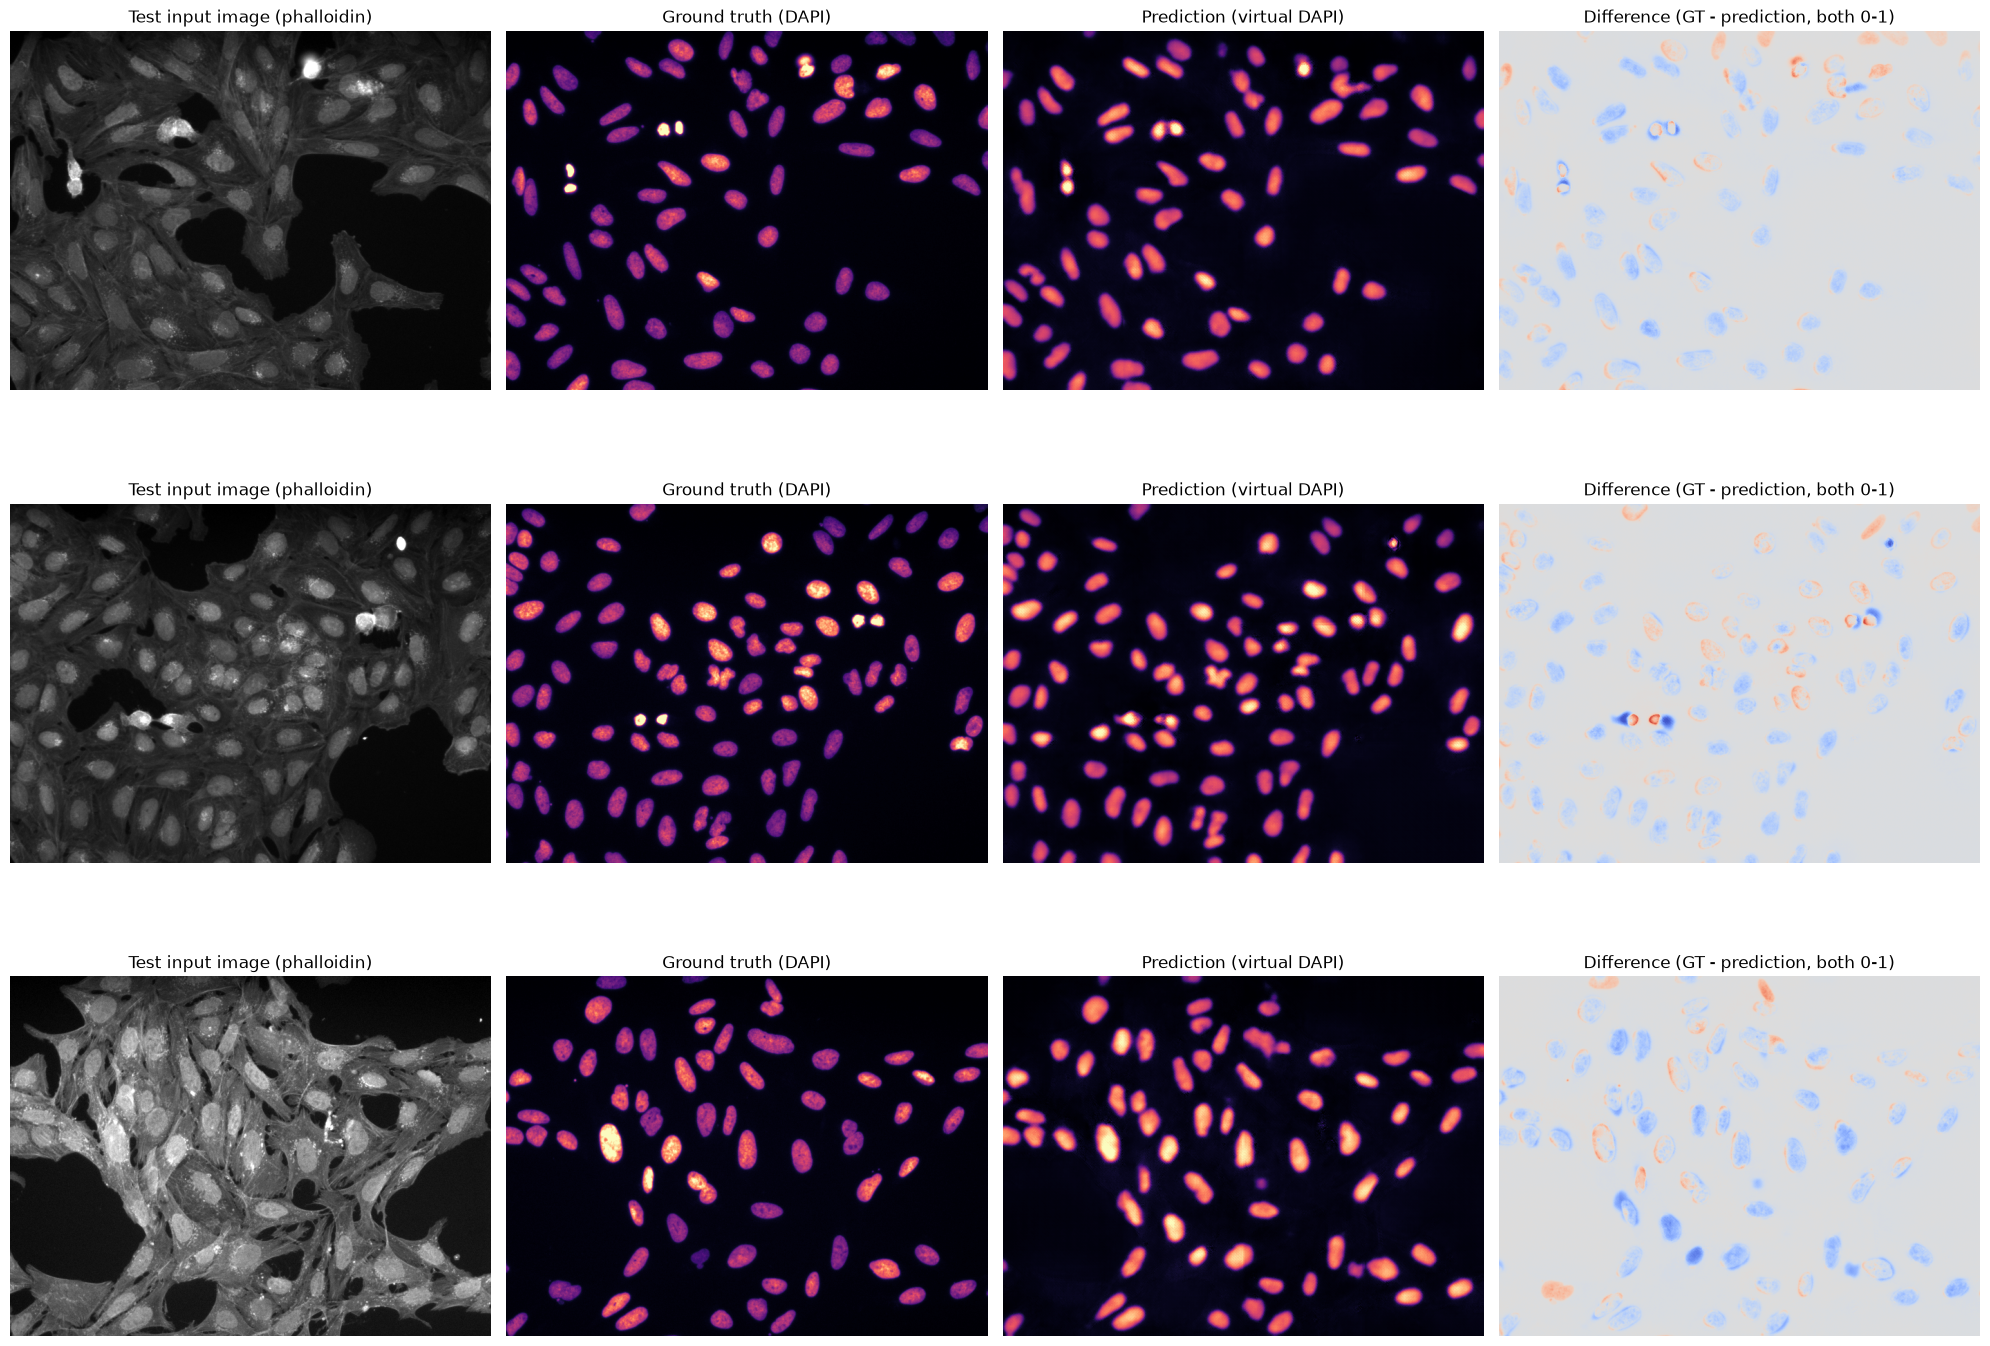

In [6]:
#@markdown ##Play to visualize some results from the test set
#@markdown The trained model was applied to the test images during the run; this cell shows, for a few of them:
#@markdown 1. The original **Test input image** (phalloidin).
#@markdown 2. The **Ground truth** DAPI intensity image.
#@markdown 3. The model **Prediction** — the virtual DAPI image.
#@markdown 4. The **Difference** between ground truth and prediction, after both are put on a common 0-1 scale.

%matplotlib inline
import os
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
from IPython.display import display, Markdown as md

# Same run_id as the training cell; default to 1 if this cell is run on its own.
try:
    run_id
except NameError:
    run_id = 1

final_results = os.path.join(output_path, job_name, 'results', job_name + '_' + str(run_id))
prediction_results = os.path.join(final_results, 'per_image')

if not os.path.isdir(prediction_results):
    raise FileNotFoundError(
        "Test predictions not found: {}\n"
        "Re-run the config cell and the training cell with TEST.ENABLE = True "
        "(and a matching run_id) so BiaPy writes the test-set predictions.".format(prediction_results)
    )

display(md("Resulting images are in `{}`".format(prediction_results)))


def norm01(img, low=0.1, high=99.9):
    """Stretch an image to 0-1 using its own percentiles.

    The prediction does not come back on the same intensity scale as the DAPI ground truth:
    BiaPy normalizes each image before training and, at prediction time, undoes that using the
    *input* image's statistics — it cannot know the target's. Phalloidin and DAPI are different
    channels with different brightness, so the prediction lands on the input's scale. Only the
    structure matters for what we do next (segmenting nuclei), so each panel gets its own
    stretch instead of being forced onto a shared scale.
    """
    img = np.asarray(img, dtype=np.float32)
    lo, hi = np.percentile(img, low), np.percentile(img, high)
    return np.clip((img - lo) / (hi - lo + 1e-9), 0, 1)


ids_pred = sorted(f for f in os.listdir(prediction_results) if f.lower().endswith(('.tif', '.tiff', '.png')))
ids_input = sorted(f for f in os.listdir(test_data_path) if f.lower().endswith(('.tif', '.tiff', '.png')))
ids_gt = sorted(f for f in os.listdir(test_data_gt_path) if f.lower().endswith(('.tif', '.tiff', '.png')))

n_available = min(len(ids_input), len(ids_pred), len(ids_gt))
samples_to_show = min(n_available, 3)
rng = np.random.default_rng(1)
chosen_images = rng.choice(n_available, samples_to_show, replace=False)

test_samples, test_sample_preds, test_sample_gt = [], [], []
for k in chosen_images:
    test_samples.append(imread(os.path.join(test_data_path, ids_input[k])))
    test_sample_preds.append(imread(os.path.join(prediction_results, ids_pred[k])).squeeze())
    test_sample_gt.append(imread(os.path.join(test_data_gt_path, ids_gt[k])))

plt.figure(figsize=(20, 5 * samples_to_show))
index = 1
for j in range(samples_to_show):
    gt = norm01(test_sample_gt[j])
    pred = norm01(test_sample_preds[j])

    plt.subplot(samples_to_show, 4, index)
    plt.title("Test input image (phalloidin)")
    plt.imshow(norm01(test_samples[j]), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')

    index += 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Ground truth (DAPI)")
    plt.imshow(gt, cmap='magma', vmin=0, vmax=1)
    plt.axis('off')

    index += 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Prediction (virtual DAPI)")
    plt.imshow(pred, cmap='magma', vmin=0, vmax=1)
    plt.axis('off')

    index += 1
    plt.subplot(samples_to_show, 4, index)
    plt.title("Difference (GT - prediction, both 0-1)")
    diff = gt - pred
    plt.imshow(diff, cmap='coolwarm', vmin=-1, vmax=1)
    plt.axis('off')

    index += 1
plt.tight_layout()
plt.show()

## Did the training converge?

The loss should go down, and PSNR / SSIM should go up (a higher PSNR or SSIM means the prediction is closer to
the ground truth). If the training loss keeps falling while the validation loss starts rising, the network is
memorising the training images instead of learning something general: that is overfitting, and it is the moment
to stop.

Take the absolute numbers in `test_results_metrics.csv` with a pinch of salt. PSNR, MAE and MSE all compare raw
pixel values, and the prediction comes back on the *input* channel's intensity scale rather than the DAPI one
(see the note in the results cell above). A large part of the reported error is therefore just that offset, not a
structural mistake — on this data it makes PSNR look roughly 9 dB worse than it really is. Judge the model on the
images, on the shape of the curves, and above all on whether you can still segment nuclei in the result.

In [ ]:
#@markdown ##Play the cell to show a plot of training error vs. epoch number and a quality metric vs epoch number
import os
import matplotlib.pyplot as plt
from skimage.io import imread

# Use the same run_id as the training cell; default to 1 if this cell is run on its own.
try:
    run_id
except NameError:
    run_id = 1

plot_dir = os.path.join(output_path, job_name, 'results', job_name + '_' + str(run_id), 'charts')
if not os.path.isdir(plot_dir):
    raise FileNotFoundError(
        "Charts folder not found: {}\n"
        "Run the training cell above first (and make sure its run_id matches).".format(plot_dir)
    )

plots = sorted(f for f in os.listdir(plot_dir) if f.lower().endswith('.png'))

loss_file = [x for x in plots if "loss" in x][0]
loss_plot = imread(os.path.join(plot_dir, loss_file))

first_metric_file = [x for x in plots if "loss" not in x][0]
metric_plot = imread(os.path.join(plot_dir, first_metric_file))

fig = plt.figure(figsize=(20, 10))
ax1 = plt.subplot(1, 2, 1)
_ = plt.imshow(loss_plot)
_ = plt.axis('off')
ax1.set_title('Training error vs epoch number', fontdict={'fontsize': 22})

ax2 = plt.subplot(1, 2, 2)
_ = plt.imshow(metric_plot)
_ = plt.axis('off')
_ = ax2.set_title(first_metric_file.replace('.png', '') + ' vs epoch number', fontdict={'fontsize': 22})

# Play with the settings

The run above used the settings in the template YAML. Almost none of them are
obviously right — they are choices, and changing them changes the result.

## What to try

### The architecture

`MODEL.ARCHITECTURE` selects the network itself. The template already uses `attention_unet` — BiaPy's own
default for image-to-image, which adds attention gates that help the decoder focus on the relevant parts of the
encoder features. Other options include `unet`, `resunet`, `seunet`, `multiresunet`, as well as networks built
specifically for image restoration and super-resolution, such as `edsr`, `rcan`, `dfcan` and `wdsr`.

- `{'MODEL.ARCHITECTURE': 'unet'}`

Compare the plain `unet` against the template's `attention_unet` before trying anything more exotic — the
difference it makes is worth knowing before spending time elsewhere.

### The loss function

`LOSS.TYPE` decides what "close" means between the prediction and the DAPI ground truth:

- `MAE` (default) — mean absolute error: the average pixel-wise difference. Robust to a few very bright outlier
  pixels (e.g. debris).
- `MSE` — mean squared error: penalises large errors much more than small ones.
- `SSIM` — structural similarity: rewards matching local patterns of intensity (edges, texture), not just raw
  pixel values.
- `W_MAE_SSIM` / `W_MSE_SSIM` — a weighted combination of the two, via `LOSS.WEIGHTS`, e.g. `[0.66, 0.34]`.

- `{'LOSS.TYPE': 'SSIM'}`

Look at the difference maps above: does a different loss change *where* the errors are (bright nuclei vs. faint
ones, edges vs. interiors)?

### 1. Augmentation

Augmentation shows the network rotated and flipped copies of the training images, so
that it does not learn that nuclei only appear in one orientation. With few training
images it usually matters a lot.

- `AUGMENTOR.ENABLE` — off, as in the example above
- `AUGMENTOR.ELASTIC` — deform the image, so shapes vary as well as orientations
- `AUGMENTOR.BRIGHTNESS` with `AUGMENTOR.BRIGHTNESS_FACTOR` — vary the intensity

Be careful with brightness augmentation here: the network's job is to *predict* intensity, so distorting the
target's brightness relationship to the input can teach it the wrong thing. Geometric augmentations (rotation,
flips, elastic) are safer than intensity ones for this task.

### Patch size and batch size

- `DATA.PATCH_SIZE` — the crops the network sees, for example `'(128, 128, 1)'`
- `TRAIN.BATCH_SIZE` — how many crops go through the network at once

Smaller patches give more crops per image and fit in less memory, but each crop shows
the network less context. These two settings together decide whether
the run fits on the GPU, so if you run out of memory, this is where to look.

### Learning rate

- `TRAIN.LR` — how large a step the network takes at each update, `1e-4` in the
  template

Ten times larger and the loss curve becomes unstable; ten times smaller and it improves
very slowly. The shape of the loss curve tells you which of the two is happening.

### Fine-tuning instead of starting from nothing

All of the above trains from scratch. You can also start from the weights of a model
that was already trained — for instance the checkpoint from your `training_semantic.ipynb` run, or from a
previous image-to-image run:

- `MODEL.LOAD_CHECKPOINT: True`
- `PATHS.CHECKPOINT_FILE` — the checkpoint to start from
- `MODEL.ITEMS_TO_LOAD_FROM_CHECKPOINT` — `['weights', 'model_arch']` for fine-tuning
- `MODEL.SKIP_UNMATCHED_LAYERS: True` when the output does not have the same shape

Note that a checkpoint trained for instance segmentation predicts a different kind of output (background/contour
channels) than an image-to-image model (a single intensity channel), so `MODEL.SKIP_UNMATCHED_LAYERS: True` is
needed to reuse only the shared encoder layers.

## Exercise: is the virtual DAPI good enough to segment?

The point of this whole exercise was to avoid spending a channel on DAPI. So the real test is not "does the
prediction look like DAPI", but "can I still find nuclei in it":

1. Take the predicted images in `training_output/<job_name>/results/<job_name>_<run_id>/per_image/`.
2. Run the pretrained StarDist model from `data_collection_IDR_stardist.ipynb` on them, exactly as it was run on
   the real DAPI channel.
3. Compare the resulting nuclei counts and outlines against StarDist run on the real DAPI ground truth.

If the counts and shapes line up, the virtual channel is doing its job — you no longer need to image DAPI at all
to find nuclei from phalloidin.

## Next

`training_semantic.ipynb` trains a model that draws nuclei outlines directly; this notebook trains one that
reconstructs the DAPI channel itself. In `evaluation.ipynb` you can compare the direct instance-segmentation
model against segmenting the virtual DAPI image produced here, and decide which approach better fits your
downstream question.